# Rectification to a Sentinel-3 OLCI scene

In this notebook, we apply the rectification algorithm to a Setninel-3 OLCI Level-1b scene. The Sentinel-3 OLCI Level-1b product comes with **2D coordinates** – irregular grids where each pixel has its own pair of x/y orlat/lon coordinates. We will there rectify the dataset to a regular grid. 




In [1]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from xcube_resampling.rectify import rectify_dataset

In [2]:
%%time
source_ds = xr.open_zarr("./inputdata/S3-OLCI-L2A.zarr.zip", consolidated=False)
source_ds

CPU times: user 354 ms, sys: 49.8 ms, total: 404 ms
Wall time: 404 ms


<xarray.Dataset> Size: 72MB
Dimensions:        (y: 1890, x: 1189)
Coordinates:
    lat            (y, x) float64 18MB dask.array<chunksize=(512, 512), meta=np.ndarray>
    lon            (y, x) float64 18MB dask.array<chunksize=(512, 512), meta=np.ndarray>
Dimensions without coordinates: y, x
Data variables:
    quality_flags  (y, x) uint32 9MB dask.array<chunksize=(512, 512), meta=np.ndarray>
    rtoa_3         (y, x) float32 9MB dask.array<chunksize=(512, 512), meta=np.ndarray>
    rtoa_6         (y, x) float32 9MB dask.array<chunksize=(512, 512), meta=np.ndarray>
    rtoa_8         (y, x) float32 9MB dask.array<chunksize=(512, 512), meta=np.ndarray>
Attributes:
    Conventions:   CF-1.4
    product_type:  C2RCC_OLCI
    start_date:    04-JUL-2018 09:21:55.677316
    stop_date:     04-JUL-2018 09:23:18.811790

The provided coordinates, latitude (`lat`) and longitude (`lon`), are *terrain-corrected* 
using a digital elevation model (DEM) that approximates the Earth's actual fractal 
surface. As a result, the gradient vectors do not vary monotonically across the scene. Instead, 
they reflect the surface roughness captured by the DEM. Areas of high terrain 
variability are highlighted in the right figure below.

CPU times: user 835 ms, sys: 166 ms, total: 1 s
Wall time: 881 ms


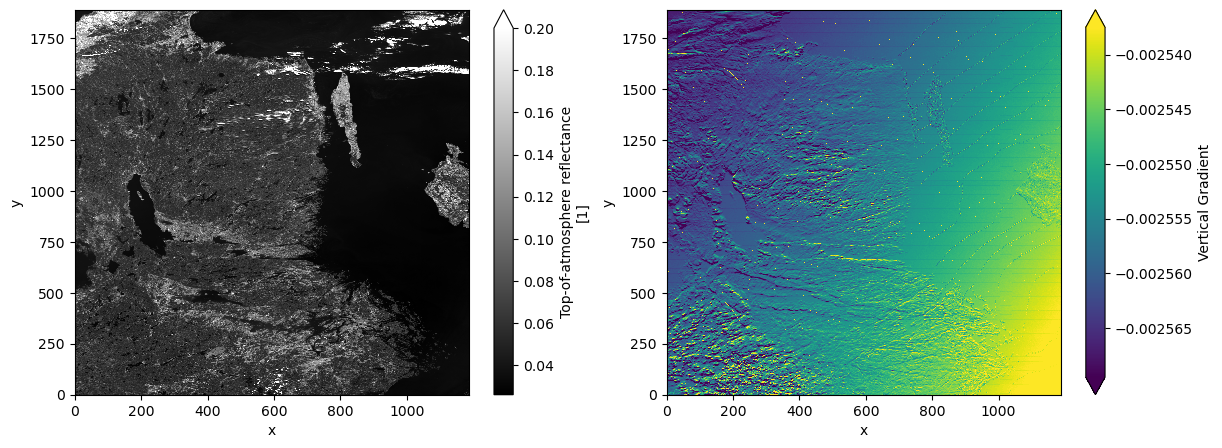

In [3]:
%%time
lon_grad = source_ds.lat.differentiate("y").rename("Vertical Gradient")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
source_ds.rtoa_8.plot(ax=ax[0], cmap="gray", vmax=0.2)
lon_grad.plot(ax=ax[1], cmap="viridis", robust=True)

Now, we can rectify the dataset. Note that this can be done with the `resample_in_space` method. 

In [4]:
%%time
target_ds = rectify_dataset(source_ds, interp_methods="nearest")
target_ds

CPU times: user 600 ms, sys: 42.4 ms, total: 642 ms
Wall time: 371 ms


<xarray.Dataset> Size: 98MB
Dimensions:        (lon: 2867, lat: 2133)
Coordinates:
  * lon            (lon) float64 23kB 12.69 12.7 12.7 12.7 ... 20.0 20.01 20.01
  * lat            (lat) float64 17kB 60.64 60.64 60.64 ... 55.21 55.2 55.2
    spatial_ref    int64 8B 0
Data variables:
    quality_flags  (lat, lon) uint32 24MB dask.array<chunksize=(512, 512), meta=np.ndarray>
    rtoa_3         (lat, lon) float32 24MB dask.array<chunksize=(512, 512), meta=np.ndarray>
    rtoa_6         (lat, lon) float32 24MB dask.array<chunksize=(512, 512), meta=np.ndarray>
    rtoa_8         (lat, lon) float32 24MB dask.array<chunksize=(512, 512), meta=np.ndarray>
Attributes:
    Conventions:   CF-1.4
    product_type:  C2RCC_OLCI
    start_date:    04-JUL-2018 09:21:55.677316
    stop_date:     04-JUL-2018 09:23:18.811790

CPU times: user 2.82 s, sys: 378 ms, total: 3.2 s
Wall time: 1.76 s


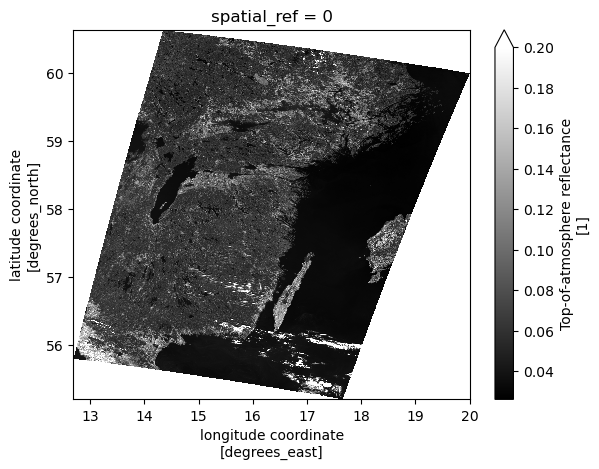

In [5]:
%%time
target_ds.rtoa_8.plot(cmap="gray", vmax=0.2)

You can also change the chunk size in the output dataset with the keyword argument `tile_size`. Note that `interp_methods=0` is identical to `interp_methods="nearest"`.

In [6]:
%%time
target_ds = rectify_dataset(source_ds, interp_methods=0, tile_size=2048)
target_ds

CPU times: user 417 ms, sys: 33.7 ms, total: 451 ms
Wall time: 360 ms


<xarray.Dataset> Size: 98MB
Dimensions:        (lon: 2867, lat: 2133)
Coordinates:
  * lon            (lon) float64 23kB 12.69 12.7 12.7 12.7 ... 20.0 20.01 20.01
  * lat            (lat) float64 17kB 60.64 60.64 60.64 ... 55.21 55.2 55.2
    spatial_ref    int64 8B 0
Data variables:
    quality_flags  (lat, lon) uint32 24MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    rtoa_3         (lat, lon) float32 24MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    rtoa_6         (lat, lon) float32 24MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    rtoa_8         (lat, lon) float32 24MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
Attributes:
    Conventions:   CF-1.4
    product_type:  C2RCC_OLCI
    start_date:    04-JUL-2018 09:21:55.677316
    stop_date:     04-JUL-2018 09:23:18.811790

CPU times: user 1.59 s, sys: 145 ms, total: 1.74 s
Wall time: 1.36 s


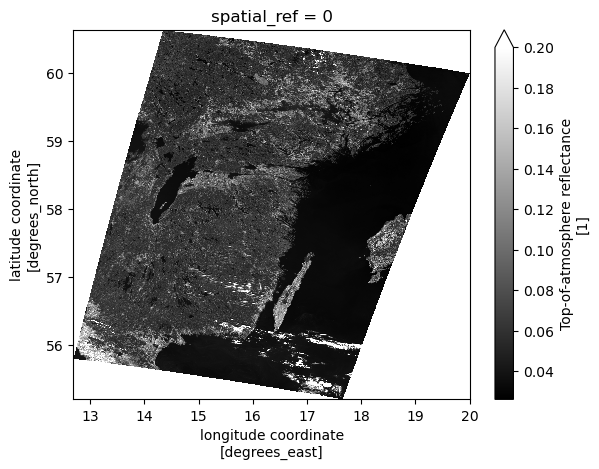

In [7]:
%%time
target_ds.rtoa_8.plot(cmap="gray", vmax=0.2)

We can also apply a different interpolation method, as shown in the next cell. 

In [8]:
%%time
target_ds_bilin = rectify_dataset(source_ds, interp_methods="bilinear")
target_ds_bilin

CPU times: user 495 ms, sys: 22.9 ms, total: 517 ms
Wall time: 336 ms


<xarray.Dataset> Size: 98MB
Dimensions:        (lon: 2867, lat: 2133)
Coordinates:
  * lon            (lon) float64 23kB 12.69 12.7 12.7 12.7 ... 20.0 20.01 20.01
  * lat            (lat) float64 17kB 60.64 60.64 60.64 ... 55.21 55.2 55.2
    spatial_ref    int64 8B 0
Data variables:
    quality_flags  (lat, lon) uint32 24MB dask.array<chunksize=(512, 512), meta=np.ndarray>
    rtoa_3         (lat, lon) float32 24MB dask.array<chunksize=(512, 512), meta=np.ndarray>
    rtoa_6         (lat, lon) float32 24MB dask.array<chunksize=(512, 512), meta=np.ndarray>
    rtoa_8         (lat, lon) float32 24MB dask.array<chunksize=(512, 512), meta=np.ndarray>
Attributes:
    Conventions:   CF-1.4
    product_type:  C2RCC_OLCI
    start_date:    04-JUL-2018 09:21:55.677316
    stop_date:     04-JUL-2018 09:23:18.811790

CPU times: user 3.18 s, sys: 210 ms, total: 3.39 s
Wall time: 1.66 s


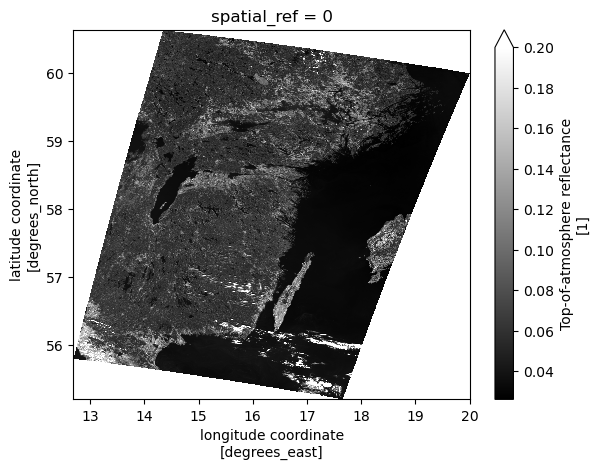

In [9]:
%%time
target_ds_bilin.rtoa_8.plot(cmap="gray", vmax=0.2)

Next, we visualize the difference between bilinear and nearest-neighbor interpolation.

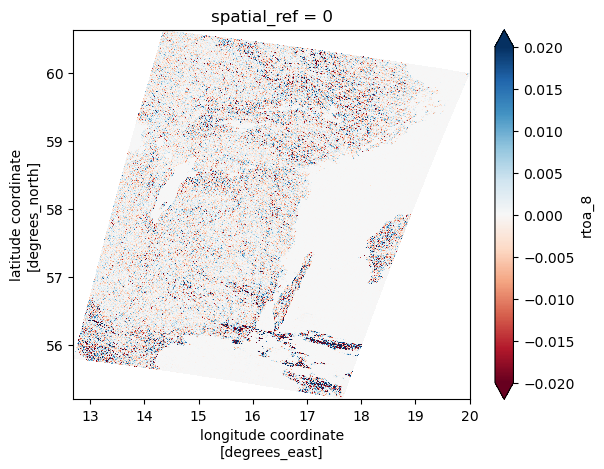

In [10]:
(target_ds_bilin.rtoa_8 - target_ds.rtoa_8).plot(vmin=-0.02, vmax=+0.02, cmap="RdBu")